In [7]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

from skimage.feature import hog
from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm

In [8]:
BASE_DIR = Path(".")  # pokrenuti notebook iz MU1_projekat foldera
TEST_SPEAKERS = {"spk04", "spk08", "spk14", "spk26", "spk28"}

ROI_SIZE = (96, 96)
FRAME_SKIP = 2
MAX_FRAMES = 150

HOG_PARAMS = {
    "orientations": 12,
    "pixels_per_cell": (8, 8),
    "cells_per_block": (3, 3),
    "block_norm": "L2-Hys"
}



In [9]:
def extract_geometry(frame):

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray,30,255,cv2.THRESH_BINARY)

    contours,_ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    cnt = max(contours,key=cv2.contourArea)

    x,y,w,h = cv2.boundingRect(cnt)

    mouth_width = w
    mouth_height = h
    mouth_ratio = w/(h+1e-6)
    mouth_area = w*h

    return [
        mouth_height,
        mouth_width,
        mouth_ratio,
        mouth_area
    ]

In [10]:
def extract_features_from_video(video_path):

    cap = cv2.VideoCapture(video_path)

    geom_features = []
    hog_features = []
    hog_diff_features = []

    prev_hog = None

    frame_id = 0

    while True:

        ret, frame = cap.read()
        if not ret:
            break

        frame_id += 1

        if frame_id % FRAME_SKIP != 0:
            continue

        geom = extract_geometry(frame)
        if geom is None:
            continue

        geom_features.append(geom)

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        coords = np.column_stack(np.where(gray > 10))

        if len(coords) > 0:

            y0, x0 = coords.min(axis=0)
            y1, x1 = coords.max(axis=0)

            gray = gray[y0:y1, x0:x1]

            h, w = gray.shape

            gray = gray[int(h*0.4):int(h*0.75), int(w*0.25):int(w*0.75)]

        gray = cv2.resize(gray, ROI_SIZE)
        gray = cv2.equalizeHist(gray)

        hog_vec = hog(
            gray,
            visualize=False,
            **HOG_PARAMS
        )

        hog_features.append(hog_vec)

        # TEMPORAL GRADIENT HOG
        if prev_hog is not None:
            hog_diff = hog_vec - prev_hog
            hog_diff_features.append(hog_diff)

        prev_hog = hog_vec

        if len(geom_features) >= MAX_FRAMES:
            break

    cap.release()

    if len(geom_features) < 5:
        return None

    geom_features = np.array(geom_features)
    hog_features = np.array(hog_features)

    if len(hog_diff_features) > 0:
        hog_diff_features = np.array(hog_diff_features)
    else:
        hog_diff_features = np.zeros_like(hog_features)

    openings = geom_features[:,0]

    delta = np.diff(openings)
    delta2 = np.diff(delta)

    peaks,_ = find_peaks(openings,distance=5)

    duration = len(openings)

    speech_rate = len(peaks) / duration
    open_range = np.max(openings) - np.min(openings)
    open_mean = np.mean(openings)
    open_std = np.std(openings)
    open_ratio = np.mean(openings > open_mean)

    return {
        "geom_per_frame":geom_features,
        "hog_per_frame":hog_features,
        "hog_diff_per_frame":hog_diff_features,

        "delta_mean":np.mean(delta),
        "delta_std":np.std(delta),
        "delta2_mean":np.mean(delta2),
        "delta2_std":np.std(delta2),

        "num_peaks":len(peaks),

        "speech_rate":speech_rate,
        "open_range":open_range,
        "open_mean":open_mean,
        "open_std":open_std,
        "open_ratio":open_ratio
    }

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def debug_roi(video_path):

    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    coords = np.column_stack(np.where(gray > 10))

    if len(coords) > 0:

        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0)

        gray = gray[y0:y1, x0:x1]

        h, w = gray.shape

        gray = gray[int(h*0.4):int(h*0.75), int(w*0.25):int(w*0.75)]

    gray = cv2.resize(gray, (64,64))

    plt.figure(figsize=(4,4))
    plt.imshow(gray, cmap="gray")
    plt.title("ROI koji ide u HOG")
    plt.axis("off")
    plt.show()

In [12]:
def aggregate_features(features):

    geom = features["geom_per_frame"]
    hog  = features["hog_per_frame"]
    hog_diff = features["hog_diff_per_frame"]

    # GEOMETRY
    geom_mean = np.mean(geom, axis=0)
    geom_std  = np.std(geom, axis=0)

    # HOG TEMPORAL POOLING
    hog_mean = np.mean(hog, axis=0)
    hog_std  = np.std(hog, axis=0)
    hog_max  = np.max(hog, axis=0)

    # TEMPORAL HOG
    hog_diff_mean = np.mean(hog_diff, axis=0)
    hog_diff_std  = np.std(hog_diff, axis=0)

    # DYNAMICS
    dynamics = np.array([
        features["delta_mean"],
        features["delta_std"],
        features["delta2_mean"],
        features["delta2_std"],
        features["num_peaks"],
        features["speech_rate"],
        features["open_range"],
        features["open_mean"],
        features["open_std"],
        features["open_ratio"]
    ])

    return np.concatenate([
        geom_mean,
        geom_std,
        hog_mean,
        hog_std,
        hog_max,
        hog_diff_mean,
        hog_diff_std,
        dynamics
    ])

In [13]:
def collect_samples(base_dir):

    samples = []

    speakers_dir = base_dir / "speakers"

    for spk_dir in sorted(speakers_dir.glob("spk*")):

        speaker = spk_dir.name

        meta_file = spk_dir / f"{speaker}_metadata.xlsx"
        meta = pd.read_excel(meta_file)

        for _, row in meta.iterrows():

            if pd.isna(row["language"]):
                continue

            lang = row["language"]
            label = 0 if lang == "ser" else 1

            video_path = (
                spk_dir /
                lang /
                "video_a_anonymized" /
                (row["name"] + ".mp4")
            )

            if video_path.exists():

                samples.append({
                    "video": str(video_path),
                    "label": label,
                    "speaker": speaker
                })

    return pd.DataFrame(samples)

In [13]:
spk = Path("speakers/spk01/ser/video_a_anonymized")
print(spk.exists())
print(list(spk.glob("*.mp4"))[:5])

True
[PosixPath('speakers/spk01/ser/video_a_anonymized/spk01_000.mp4'), PosixPath('speakers/spk01/ser/video_a_anonymized/spk01_013.mp4'), PosixPath('speakers/spk01/ser/video_a_anonymized/spk01_012.mp4'), PosixPath('speakers/spk01/ser/video_a_anonymized/spk01_016.mp4'), PosixPath('speakers/spk01/ser/video_a_anonymized/spk01_009.mp4')]


In [14]:
print(list((BASE_DIR/"speakers").glob("spk*")))

[PosixPath('speakers/spk01'), PosixPath('speakers/spk02'), PosixPath('speakers/spk03'), PosixPath('speakers/spk04'), PosixPath('speakers/spk05'), PosixPath('speakers/spk06'), PosixPath('speakers/spk07'), PosixPath('speakers/spk08'), PosixPath('speakers/spk09'), PosixPath('speakers/spk10'), PosixPath('speakers/spk11'), PosixPath('speakers/spk12'), PosixPath('speakers/spk13'), PosixPath('speakers/spk14'), PosixPath('speakers/spk15'), PosixPath('speakers/spk16'), PosixPath('speakers/spk17'), PosixPath('speakers/spk18'), PosixPath('speakers/spk19'), PosixPath('speakers/spk20'), PosixPath('speakers/spk21'), PosixPath('speakers/spk22'), PosixPath('speakers/spk23'), PosixPath('speakers/spk24'), PosixPath('speakers/spk25'), PosixPath('speakers/spk26'), PosixPath('speakers/spk27'), PosixPath('speakers/spk28'), PosixPath('speakers/spk29'), PosixPath('speakers/spk30')]


In [15]:
from pathlib import Path
samples = collect_samples(BASE_DIR)
print(len(samples))
print(samples.head())

4709
                                               video  label speaker
0  speakers/spk01/ser/video_a_anonymized/spk01_00...      0   spk01
1  speakers/spk01/ser/video_a_anonymized/spk01_00...      0   spk01
2  speakers/spk01/ser/video_a_anonymized/spk01_00...      0   spk01
3  speakers/spk01/ser/video_a_anonymized/spk01_00...      0   spk01
4  speakers/spk01/ser/video_a_anonymized/spk01_00...      0   spk01


In [16]:
import pandas as pd
meta = pd.read_excel("speakers/spk01/spk01_metadata.xlsx")
print(meta.head())

        name  video_a  video_r  video_l  audio  \
0  spk01_000        1        1        1      1   
1  spk01_001        1        1        1      1   
2  spk01_002        1        1        1      1   
3  spk01_003        1        1        1      1   
4  spk01_004        1        1        1      1   

                                          transcript language  common  note  
0  A B V G D Đ E Ž Z I J K L LJ M N NJ O P R S T ...      ser     1.0   NaN  
1  nula jedan dva tri četiri pet šest sedam osam ...      ser     1.0   NaN  
2                  napred nazad levo desno gore dole      ser     1.0   NaN  
3  potvrdi odustani obriši pošalji dalje početak ...      ser     1.0   NaN  
4  ponedeljak utorak sreda četvrtak petak subota ...      ser     1.0   NaN  


In [14]:
samples = collect_samples(BASE_DIR)

train_df = samples[~samples["speaker"].isin(TEST_SPEAKERS)]
test_df  = samples[samples["speaker"].isin(TEST_SPEAKERS)]

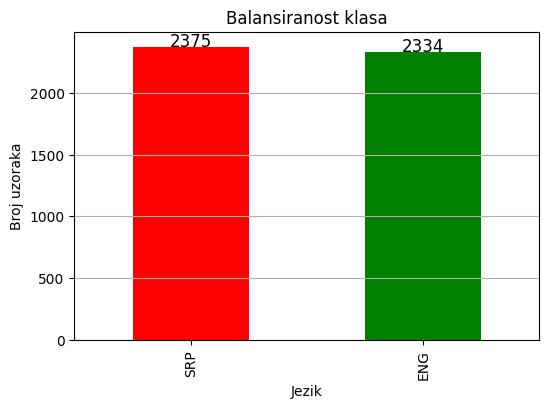

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

all_df = pd.concat([train_df, test_df])

counts = all_df["label"].value_counts().sort_index()
counts.index = ["SRP", "ENG"]

fig, ax = plt.subplots(figsize=(6,4))

counts.plot(kind="bar", color=["red", "green"], ax=ax)

# ispis tačnog broja iznad stubova
for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha="center", fontsize=12)

ax.set_title("Balansiranost klasa")
ax.set_xlabel("Jezik")
ax.set_ylabel("Broj uzoraka")
ax.grid(axis="y")

plt.show()

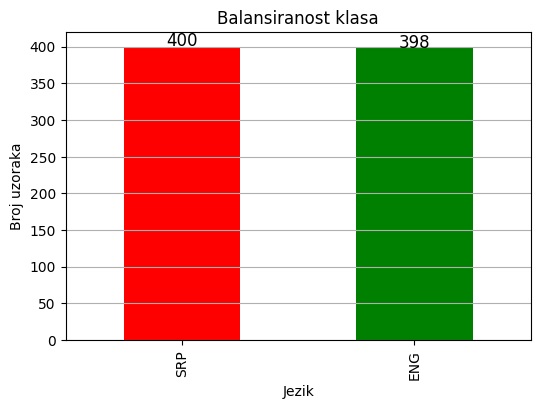

In [22]:
counts = test_df["label"].value_counts().sort_index()
counts.index = ["SRP", "ENG"]

fig, ax = plt.subplots(figsize=(6,4))

counts.plot(kind="bar", color=["red", "green"], ax=ax)

# ispis tačnog broja iznad stubova
for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha="center", fontsize=12)

ax.set_title("Balansiranost klasa")
ax.set_xlabel("Jezik")
ax.set_ylabel("Broj uzoraka")
ax.grid(axis="y")

plt.show()

In [18]:
row = train_df.iloc[0]

f = extract_features_from_video(row.video)

vec = aggregate_features(f)

print("Feature vector length:", len(vec))

Feature vector length: 54018


In [16]:
row = train_df.iloc[0]

f = extract_features_from_video(row.video)
vec = aggregate_features(f)

print("NaN count:", np.isnan(vec).sum())

NaN count: 0


In [20]:
import time

start = time.time()

row = train_df.iloc[0]
extract_features_from_video(row.video)

print("Time per video:", time.time() - start)

Time per video: 4.921973705291748


In [ ]:
def build_dataset(df):

    X = []
    y = []
    speakers = []

    for row in tqdm(df.itertuples(), total=len(df)):

        f = extract_features_from_video(row.video)

        if f is None:
            continue

        vec = aggregate_features(f)

        X.append(vec)
        y.append(row.label)
        speakers.append(row.speaker)

    return np.array(X), np.array(y), np.array(speakers)

X_train, y_train, speaker_train = build_dataset(train_df)
X_test, y_test, speaker_test = build_dataset(test_df)


In [ ]:
np.save("X_train2.npy", X_train)
np.save("X_test2.npy", X_test)

np.save("y_train2.npy", y_train)
np.save("y_test2.npy", y_test)

np.save("speaker_train2.npy", speaker_train)
np.save("speaker_test2.npy", speaker_test)

In [21]:
X_train = np.load("X_train2.npy")
X_test = np.load("X_test2.npy")
y_train = np.load("y_train2.npy")
y_test = np.load("y_test2.npy")
speaker_train = np.load("speaker_train2.npy")
speaker_test = np.load("speaker_test2.npy")

In [22]:
# Provera da li se train i test speakers preklapaju

# speaker_train i speaker_test su np.array iz build_dataset

train_speakers_set = set(speaker_train)
test_speakers_set = set(speaker_test)

# pronalazi zajednicke speakere
overlap = train_speakers_set.intersection(test_speakers_set)

if len(overlap) == 0:
    print("✅ Nema overlap-a između train i test speakers – leak nije prisutan.")
else:
    print("⚠ Upozorenje! Ovi speakeri se pojavljuju u oba seta:", overlap)

✅ Nema overlap-a između train i test speakers – leak nije prisutan.


In [28]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ===== SCALER =====
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# parametri za testiranje
pca_values = [80, 120, 150, 200, 300]
C_values = [0.5, 1, 5, 10]

best_acc = 0

for n in pca_values:
    print("\n===== PCA components:", n, "=====")
    pca = PCA(n_components=n, whiten=True)
    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)

    selector = VarianceThreshold(threshold=0.01)
    X_train_fs = selector.fit_transform(X_train_pca)
    X_test_fs = selector.transform(X_test_pca)
    print("Dimenzija posle feature selection:", X_train_fs.shape[1])

    for C in C_values:
        svm = SVC(kernel="rbf", C=C, gamma="scale")
        svm.fit(X_train_fs, y_train)
        pred = svm.predict(X_test_fs)
        acc = accuracy_score(y_test, pred)
        print("C =", C, "| Accuracy:", acc)

        # ===== ČUVANJE NAJBOLJEG =====
        if acc > best_acc:
            best_acc = acc
            joblib.dump(svm, "svm_best.pkl")
            joblib.dump(pca, "pca_svm.pkl")
            joblib.dump(scaler, "scaler_svm.pkl")
            joblib.dump(selector, "selector_svm.pkl")
            print(f"  ✅ Novi best sačuvan: acc={acc:.4f}, PCA={n}, C={C}")


===== PCA components: 80 =====
Dimenzija posle feature selection: 80
C = 0.5 | Accuracy: 0.6228070175438597
  ✅ Novi best sačuvan: acc=0.6228, PCA=80, C=0.5
C = 1 | Accuracy: 0.6015037593984962
C = 5 | Accuracy: 0.5375939849624061
C = 10 | Accuracy: 0.5137844611528822

===== PCA components: 120 =====
Dimenzija posle feature selection: 120
C = 0.5 | Accuracy: 0.6541353383458647
  ✅ Novi best sačuvan: acc=0.6541, PCA=120, C=0.5
C = 1 | Accuracy: 0.6541353383458647
C = 5 | Accuracy: 0.62531328320802
C = 10 | Accuracy: 0.6265664160401002

===== PCA components: 150 =====
Dimenzija posle feature selection: 150
C = 0.5 | Accuracy: 0.6115288220551378
C = 1 | Accuracy: 0.6102756892230576
C = 5 | Accuracy: 0.5989974937343359
C = 10 | Accuracy: 0.5802005012531328

===== PCA components: 200 =====
Dimenzija posle feature selection: 200
C = 0.5 | Accuracy: 0.581453634085213
C = 1 | Accuracy: 0.5651629072681704
C = 5 | Accuracy: 0.5551378446115288
C = 10 | Accuracy: 0.5614035087719298

===== PCA com

In [29]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# ===== SCALING =====
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ===== PARAMETRI ZA TEST =====
pca_values = [60, 80, 120, 150, 200]
best_acc = 0

mlp_architectures = [
    (128,64),
    (256,128),
    (256,128,64),
    (512,256,128)
]
learning_rates = [0.001, 0.0005]
max_iters = [400, 600]

# ===== GRID TEST =====
for pca_dim in pca_values:
    print("\n===== PCA =", pca_dim, "=====")
    pca = PCA(n_components=pca_dim, whiten=True)
    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)

    for arch in mlp_architectures:
        for lr in learning_rates:
            for it in max_iters:
                mlp = MLPClassifier(
                    hidden_layer_sizes=arch,
                    activation="relu",
                    solver="adam",
                    learning_rate_init=lr,
                    max_iter=it,
                    random_state=42
                )
                mlp.fit(X_train_pca, y_train)
                pred = mlp.predict(X_test_pca)
                acc = accuracy_score(y_test, pred)
                print(
                    "Arch:", arch,
                    "| lr:", lr,
                    "| iter:", it,
                    "| acc:", round(acc,4)
                )

                # ===== ČUVANJE NAJBOLJEG =====
                if acc > best_acc:
                    best_acc = acc
                    joblib.dump(mlp, "mlp_best.pkl")
                    joblib.dump(pca, "pca_mlp.pkl")
                    joblib.dump(scaler, "scaler_mlp.pkl")
                    print(f"  ✅ Novi best sačuvan: acc={acc:.4f}, PCA={pca_dim}, arch={arch}, lr={lr}, iter={it}")


===== PCA = 60 =====
Arch: (128, 64) | lr: 0.001 | iter: 400 | acc: 0.5063
  ✅ Novi best sačuvan: acc=0.5063, PCA=60, arch=(128, 64), lr=0.001, iter=400
Arch: (128, 64) | lr: 0.001 | iter: 600 | acc: 0.5063
Arch: (128, 64) | lr: 0.0005 | iter: 400 | acc: 0.515
  ✅ Novi best sačuvan: acc=0.5150, PCA=60, arch=(128, 64), lr=0.0005, iter=400
Arch: (128, 64) | lr: 0.0005 | iter: 600 | acc: 0.515
Arch: (256, 128) | lr: 0.001 | iter: 400 | acc: 0.5564
  ✅ Novi best sačuvan: acc=0.5564, PCA=60, arch=(256, 128), lr=0.001, iter=400
Arch: (256, 128) | lr: 0.001 | iter: 600 | acc: 0.5564
Arch: (256, 128) | lr: 0.0005 | iter: 400 | acc: 0.5376
Arch: (256, 128) | lr: 0.0005 | iter: 600 | acc: 0.5376
Arch: (256, 128, 64) | lr: 0.001 | iter: 400 | acc: 0.5414
Arch: (256, 128, 64) | lr: 0.001 | iter: 600 | acc: 0.5414
Arch: (256, 128, 64) | lr: 0.0005 | iter: 400 | acc: 0.5238
Arch: (256, 128, 64) | lr: 0.0005 | iter: 600 | acc: 0.5238
Arch: (512, 256, 128) | lr: 0.001 | iter: 400 | acc: 0.5326
Arch: 

In [30]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ===== SCALING =====
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ===== PARAMETRI =====
pca_values = [60, 80, 120, 150, 200]
n_estimators_values = [100, 300, 500]
max_depth_values = [10, 20, None]
max_features_values = ["sqrt", "log2"]

best_acc = 0

# ===== GRID TEST =====
for pca_dim in pca_values:
    print("\n===== PCA =", pca_dim, "=====")
    pca = PCA(n_components=pca_dim, whiten=True)
    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)

    for n_est in n_estimators_values:
        for depth in max_depth_values:
            for mf in max_features_values:
                rf = RandomForestClassifier(
                    n_estimators=n_est,
                    max_depth=depth,
                    max_features=mf,
                    n_jobs=-1,
                    random_state=42
                )
                rf.fit(X_train_pca, y_train)
                pred = rf.predict(X_test_pca)
                acc = accuracy_score(y_test, pred)
                print(
                    "trees:", n_est,
                    "| depth:", depth,
                    "| features:", mf,
                    "| acc:", round(acc,4)
                )

                # ===== ČUVANJE NAJBOLJEG =====
                if acc > best_acc:
                    best_acc = acc
                    joblib.dump(rf, "rf_best.pkl")
                    joblib.dump(pca, "pca_rf.pkl")
                    joblib.dump(scaler, "scaler_rf.pkl")
                    print(f"  ✅ Novi best sačuvan: acc={acc:.4f}, PCA={pca_dim}, trees={n_est}, depth={depth}, feat={mf}")


===== PCA = 60 =====
trees: 100 | depth: 10 | features: sqrt | acc: 0.599
  ✅ Novi best sačuvan: acc=0.5990, PCA=60, trees=100, depth=10, feat=sqrt
trees: 100 | depth: 10 | features: log2 | acc: 0.5777
trees: 100 | depth: 20 | features: sqrt | acc: 0.5915
trees: 100 | depth: 20 | features: log2 | acc: 0.5827
trees: 100 | depth: None | features: sqrt | acc: 0.5551
trees: 100 | depth: None | features: log2 | acc: 0.5865
trees: 300 | depth: 10 | features: sqrt | acc: 0.5802
trees: 300 | depth: 10 | features: log2 | acc: 0.5977
trees: 300 | depth: 20 | features: sqrt | acc: 0.6003
  ✅ Novi best sačuvan: acc=0.6003, PCA=60, trees=300, depth=20, feat=sqrt
trees: 300 | depth: 20 | features: log2 | acc: 0.5952
trees: 300 | depth: None | features: sqrt | acc: 0.5852
trees: 300 | depth: None | features: log2 | acc: 0.5714
trees: 500 | depth: 10 | features: sqrt | acc: 0.594
trees: 500 | depth: 10 | features: log2 | acc: 0.6028
  ✅ Novi best sačuvan: acc=0.6028, PCA=60, trees=500, depth=10, feat


  SVM
Accuracy: 0.6541

Classification Report:
              precision    recall  f1-score   support

  srpski (0)       0.68      0.60      0.63       400
engleski (1)       0.64      0.71      0.67       398

    accuracy                           0.65       798
   macro avg       0.66      0.65      0.65       798
weighted avg       0.66      0.65      0.65       798



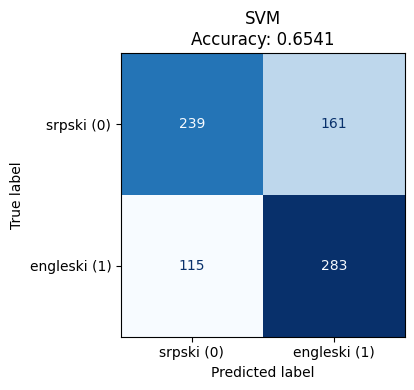


  MLP
Accuracy: 0.6303

Classification Report:
              precision    recall  f1-score   support

  srpski (0)       0.69      0.48      0.56       400
engleski (1)       0.60      0.78      0.68       398

    accuracy                           0.63       798
   macro avg       0.64      0.63      0.62       798
weighted avg       0.64      0.63      0.62       798



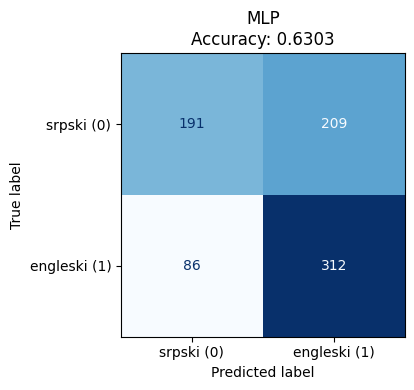


  Random Forest
Accuracy: 0.6153

Classification Report:
              precision    recall  f1-score   support

  srpski (0)       0.63      0.57      0.60       400
engleski (1)       0.61      0.66      0.63       398

    accuracy                           0.62       798
   macro avg       0.62      0.62      0.61       798
weighted avg       0.62      0.62      0.61       798



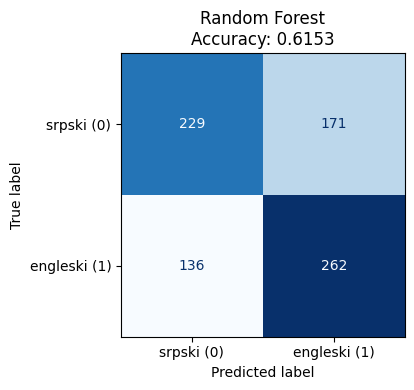

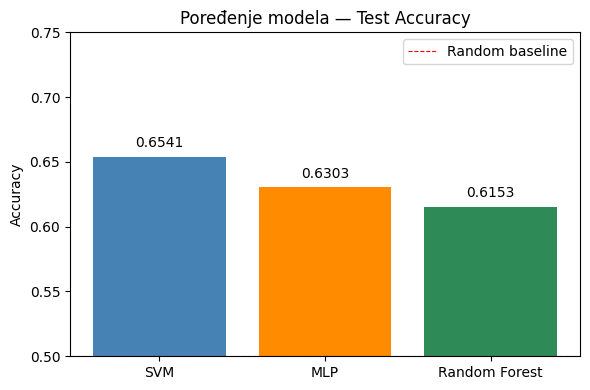

In [32]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

X_train = np.load("X_train2.npy")
X_test  = np.load("X_test2.npy")
y_train = np.load("y_train2.npy")
y_test  = np.load("y_test2.npy")

label_names = ["srpski (0)", "engleski (1)"]

def evaluate_saved(name, model, X_te, y_te):
    pred = model.predict(X_te)
    acc  = accuracy_score(y_te, pred)
    cm   = confusion_matrix(y_te, pred)
    cr   = classification_report(y_te, pred, target_names=label_names)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(cr)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAccuracy: {acc:.4f}")
    plt.tight_layout()
    plt.savefig(f"cm_{name.split()[0].lower()}.png", dpi=150)
    plt.show()

    return pred

# ===== SVM =====
scaler_svm = joblib.load("scaler_svm.pkl")
pca_svm    = joblib.load("pca_svm.pkl")
svm_best   = joblib.load("svm_best.pkl")
X_test_svm = pca_svm.transform(scaler_svm.transform(X_test))
pred_svm   = evaluate_saved("SVM", svm_best, X_test_svm, y_test)

# ===== MLP =====
scaler_mlp = joblib.load("scaler_mlp.pkl")
pca_mlp    = joblib.load("pca_mlp.pkl")
mlp_best   = joblib.load("mlp_best.pkl")
X_test_mlp = pca_mlp.transform(scaler_mlp.transform(X_test))
pred_mlp   = evaluate_saved("MLP", mlp_best, X_test_mlp, y_test)

# ===== RF =====
scaler_rf = joblib.load("scaler_rf.pkl")
pca_rf    = joblib.load("pca_rf.pkl")
rf_best   = joblib.load("rf_best.pkl")
X_test_rf = pca_rf.transform(scaler_rf.transform(X_test))
pred_rf   = evaluate_saved("Random Forest", rf_best, X_test_rf, y_test)

# ===== POREĐENJE =====
models     = ["SVM", "MLP", "Random Forest"]
accuracies = [
    accuracy_score(y_test, pred_svm),
    accuracy_score(y_test, pred_mlp),
    accuracy_score(y_test, pred_rf)
]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(models, accuracies, color=["steelblue", "darkorange", "seagreen"])
ax.set_ylim(0.5, 0.75)
ax.set_ylabel("Accuracy")
ax.set_title("Poređenje modela — Test Accuracy")
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="Random baseline")

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{acc:.4f}", ha="center", va="bottom", fontsize=10)

ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()